In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler


In [ ]:
from google.colab import files
upload = files.upload()

Saving wine-clustering.csv to wine-clustering (1).csv


In [ ]:
wine = pd.read_csv('wine-clustering.csv')
wine.head()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [ ]:
wine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Alcohol               178 non-null    float64
 1   Malic_Acid            178 non-null    float64
 2   Ash                   178 non-null    float64
 3   Ash_Alcanity          178 non-null    float64
 4   Magnesium             178 non-null    int64  
 5   Total_Phenols         178 non-null    float64
 6   Flavanoids            178 non-null    float64
 7   Nonflavanoid_Phenols  178 non-null    float64
 8   Proanthocyanins       178 non-null    float64
 9   Color_Intensity       178 non-null    float64
 10  Hue                   178 non-null    float64
 11  OD280                 178 non-null    float64
 12  Proline               178 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 18.2 KB


**Preprocessing Data**


In [ ]:
wine.isna().sum()

Alcohol                 0
Malic_Acid              0
Ash                     0
Ash_Alcanity            0
Magnesium               0
Total_Phenols           0
Flavanoids              0
Nonflavanoid_Phenols    0
Proanthocyanins         0
Color_Intensity         0
Hue                     0
OD280                   0
Proline                 0
dtype: int64

Terlihat bahwa tidak terdapat missing values

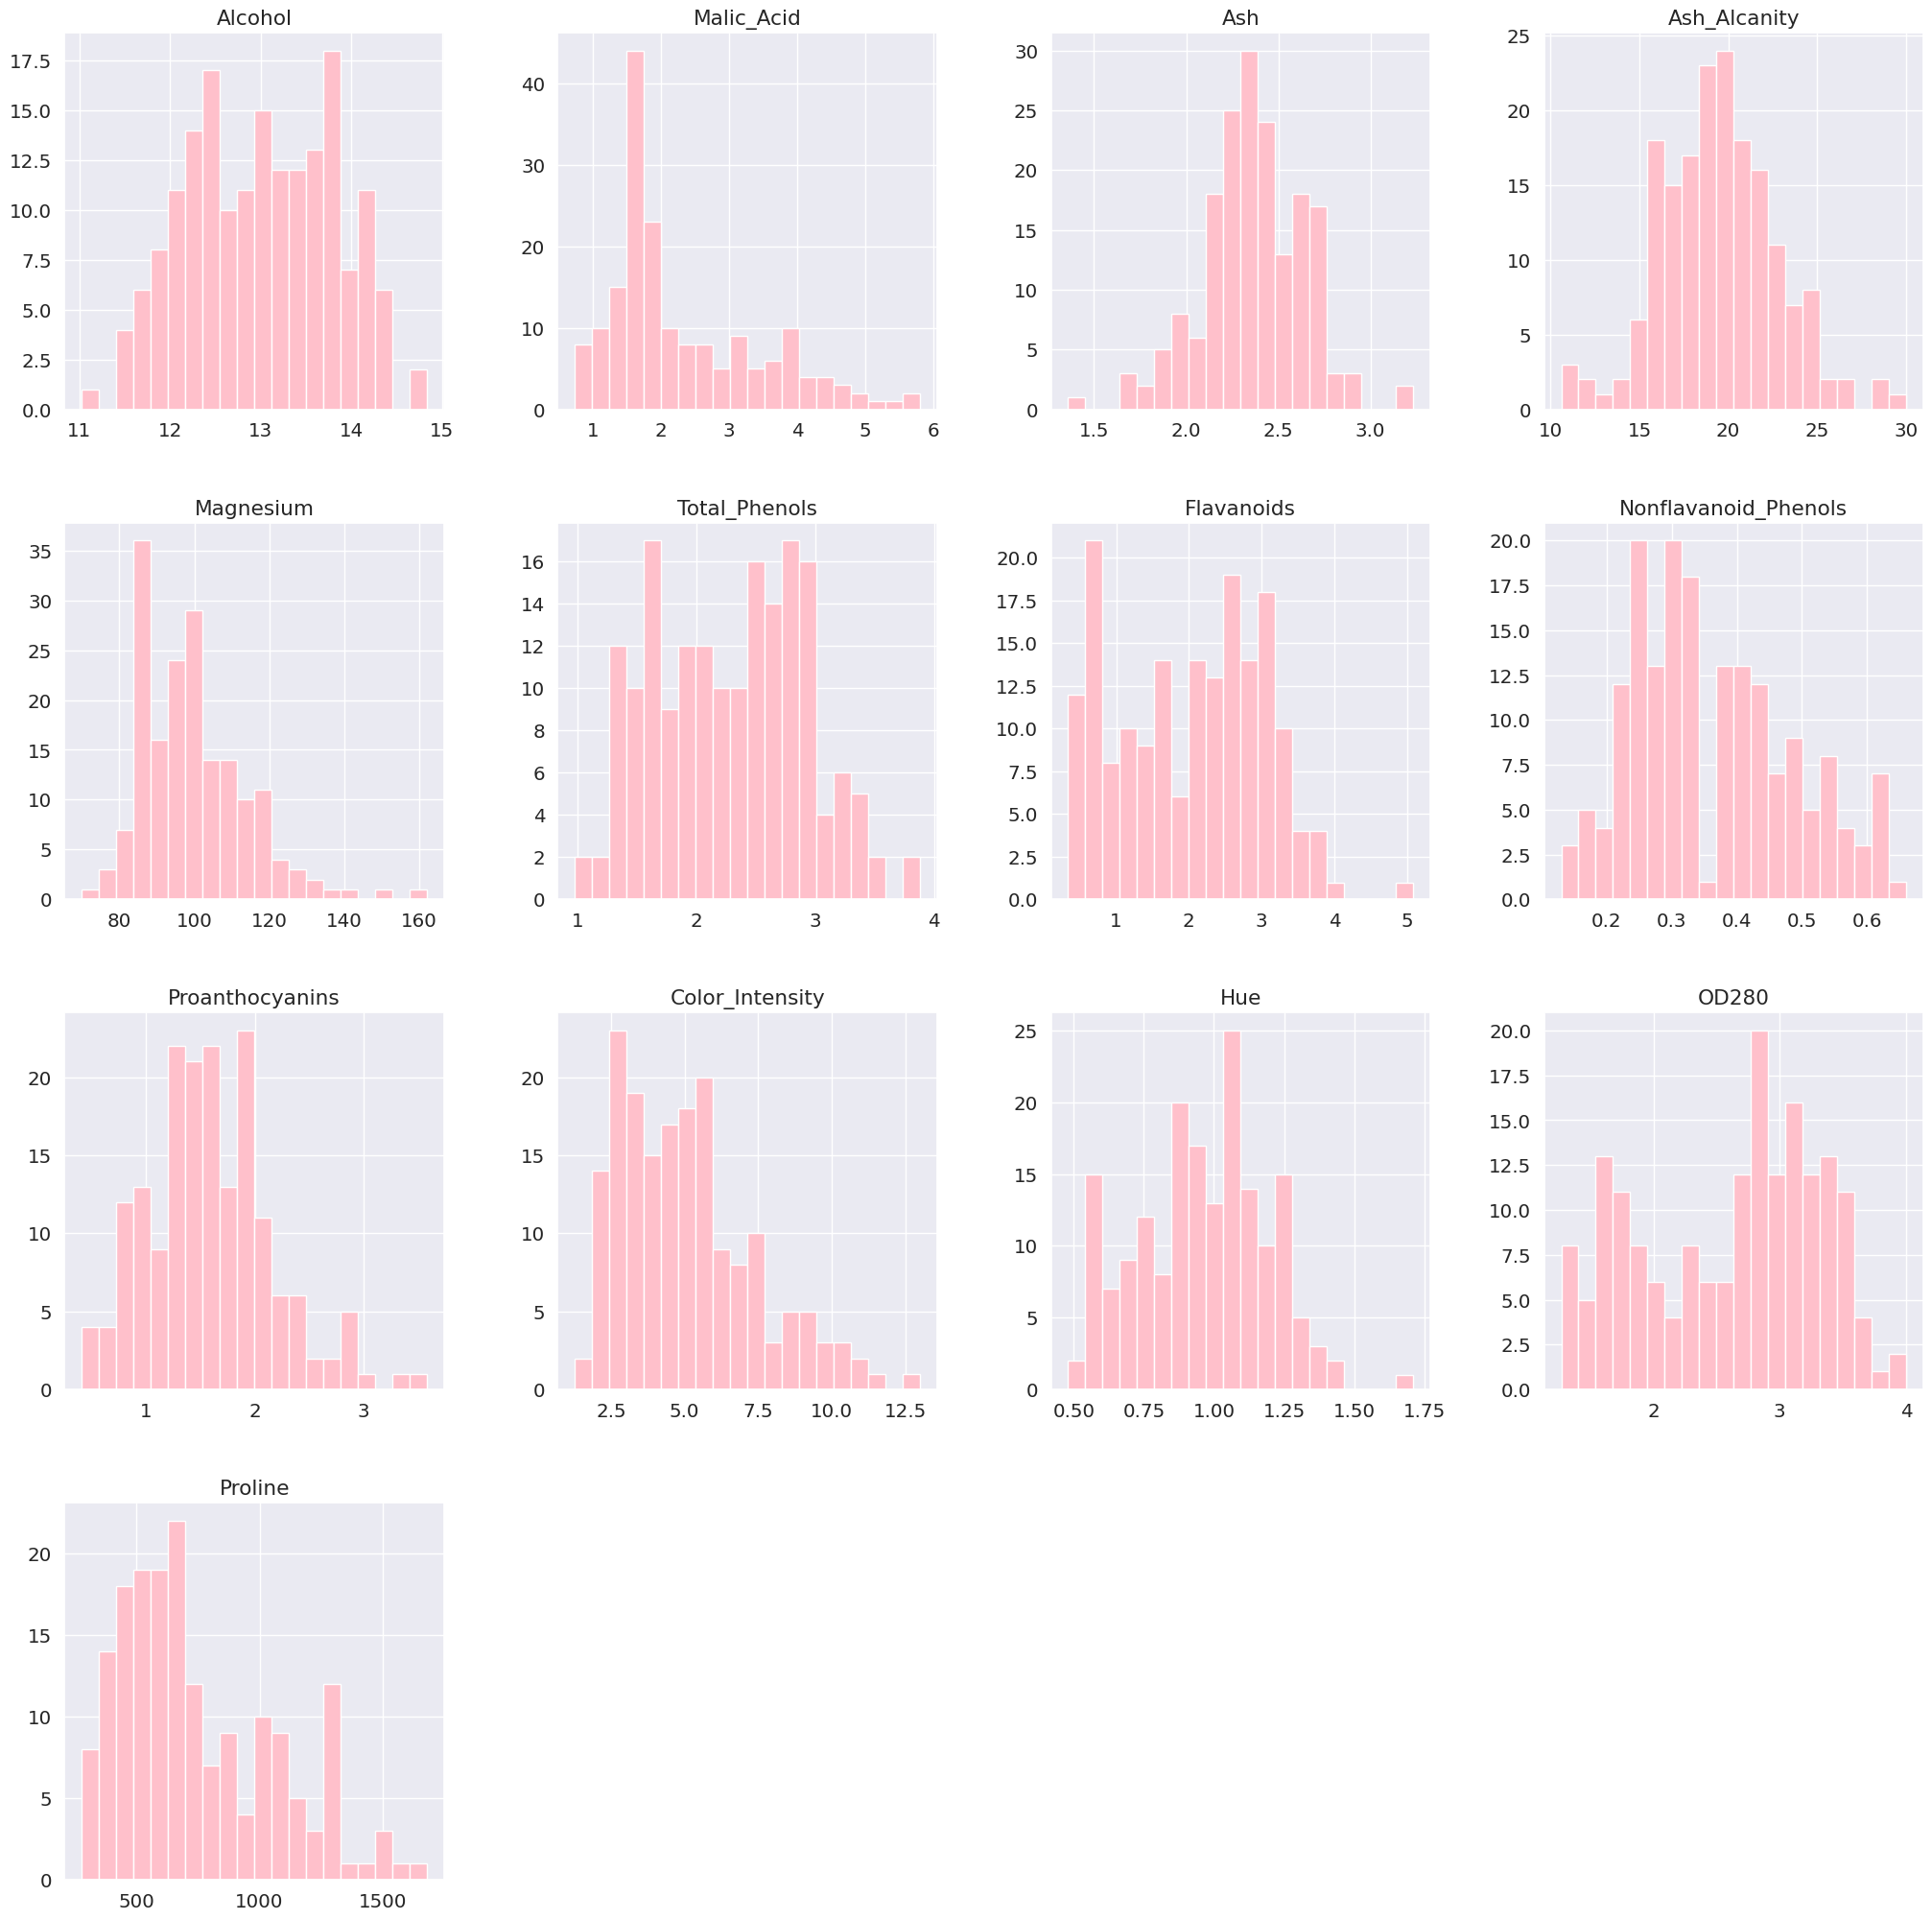

In [ ]:
#Memvisualisasi tiap kolom dengan histoplot

sns.set(style='darkgrid',font_scale=1.3, rc={'figure.figsize':(25,25)})
ax=wine.hist(bins=20,color='pink' )

Memvisualisasikan dengan boxplot untuk mengecek apakah terdapat outlier pada data

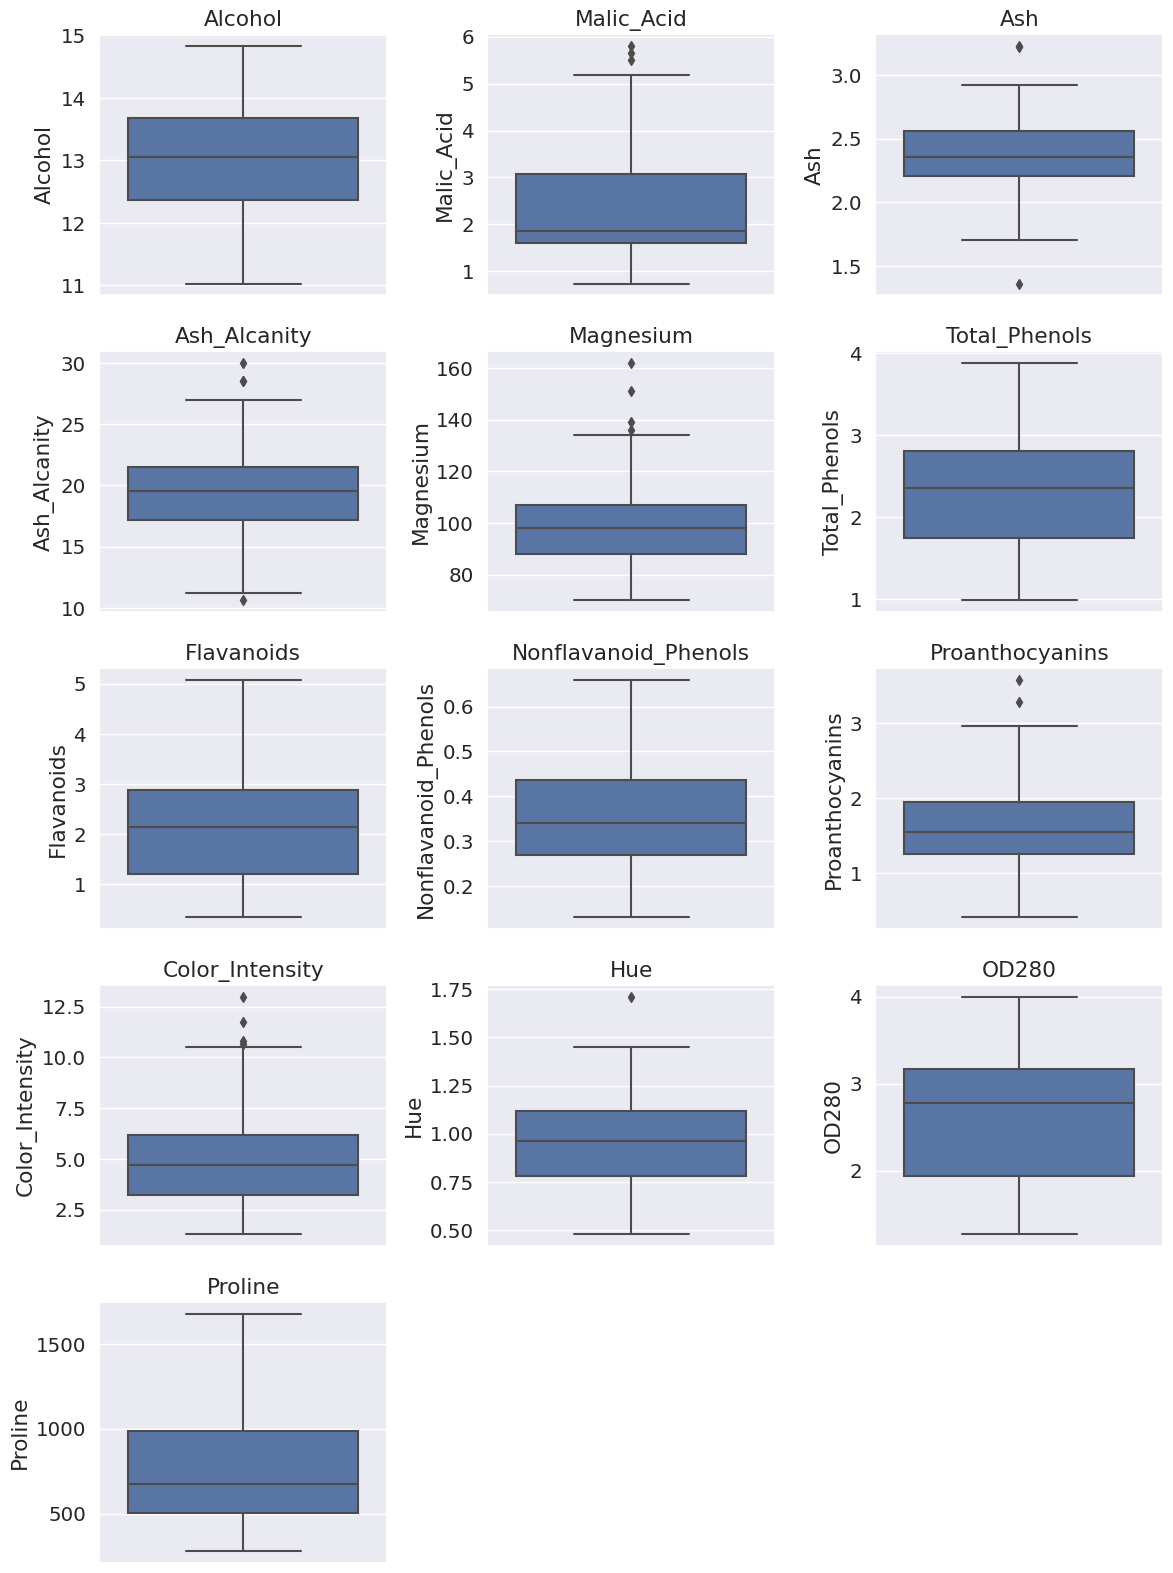

In [ ]:
plt.figure(figsize=(12, 16))

# melakukan loop pada setiap kolom untuk membuat boxplot
for column in wine.columns:
    if pd.api.types.is_numeric_dtype(wine[column]):
        plt.subplot(5, 3, wine.columns.get_loc(column) + 1)
        sns.boxplot(y=wine[column])
        plt.title(column)

plt.tight_layout()
plt.show()

In [ ]:
#Dapat dilihat pada boxplot, bahwa data terdapat outlier. Maka dari itu, perlu dilakukan penghapusan outlier dengan interquartile.

for column in range(len(wine.columns)):
    q75, q25 = np.percentile(wine[wine.columns[column]], [75, 25])
    iqr = q75 - q25
    iqrMin = q25 - (iqr * 1.5)
    iqrMax = q75 + (iqr * 1.5)
    print(wine.columns[column])
    print(f"iqrMin {iqrMin}")
    print(f"iqrMax {iqrMax}")
    print(f"Hitung IqrMin: {len(wine[wine[wine.columns[column]] < iqrMin])}")
    print(f"Hitung IqrMax: {len(wine[wine[wine.columns[column]] > iqrMax])}")
    wine = wine.drop(wine[wine[wine.columns[column]] < iqrMin].index, axis=0)
    wine = wine.drop(wine[wine[wine.columns[column]] > iqrMax].index, axis=0)

Alcohol
iqrMin 10.389999999999997
iqrMax 15.650000000000002
Hitung IqrMin: 0
Hitung IqrMax: 0
Malic_Acid
iqrMin -0.6174999999999997
iqrMax 5.3025
Hitung IqrMin: 0
Hitung IqrMax: 3
Ash
iqrMin 1.6925000000000003
iqrMax 3.0724999999999993
Hitung IqrMin: 1
Hitung IqrMax: 2
Ash_Alcanity
iqrMin 10.687500000000002
iqrMax 27.987499999999997
Hitung IqrMin: 0
Hitung IqrMax: 2
Magnesium
iqrMin 59.5
iqrMax 135.5
Hitung IqrMin: 0
Hitung IqrMax: 3
Total_Phenols
iqrMin 0.07500000000000018
iqrMax 4.435
Hitung IqrMin: 0
Hitung IqrMax: 0
Flavanoids
iqrMin -1.3099999999999996
iqrMax 5.409999999999999
Hitung IqrMin: 0
Hitung IqrMax: 0
Nonflavanoid_Phenols
iqrMin 0.017500000000000043
iqrMax 0.6775
Hitung IqrMin: 0
Hitung IqrMax: 0
Proanthocyanins
iqrMin 0.23750000000000027
iqrMax 2.9374999999999996
Hitung IqrMin: 0
Hitung IqrMax: 2
Color_Intensity
iqrMin -1.1999999999999997
iqrMax 10.719999999999999
Hitung IqrMin: 0
Hitung IqrMax: 3
Hue
iqrMin 0.3012499999999998
iqrMax 1.6112500000000003
Hitung IqrMin: 0
H

**Mengidentifikasi banyak cluster yang optimal dengan elbow plot**


In [ ]:
from sklearn.cluster import KMeans
#menscalling data
sc = StandardScaler()
wine_scaled = sc.fit_transform(wine)
wine_scaled

array([[ 1.51516332, -0.57916566,  0.27093638, ...,  0.3833328 ,
         1.82809675,  0.98217445],
       [ 0.20964771, -0.51250719, -0.93153695, ...,  0.42947949,
         1.09692792,  0.93483012],
       [ 0.15894808,  0.03980581,  1.26608672, ...,  0.33718612,
         0.77352632,  1.36092915],
       ...,
       [ 0.29837208,  1.8681523 , -0.43396178, ..., -1.69326819,
        -1.49028487,  0.25622795],
       [ 0.17162299,  0.25882648,  0.02214879, ..., -1.6471215 ,
        -1.40591924,  0.27200939],
       [ 1.38841423,  1.69674482,  1.5563389 , ..., -1.60097481,
        -1.43404112, -0.61175157]])

Inersia = jumlah kuadrat jarak data ke centroid terdekat.

In [ ]:
std_scaler = StandardScaler()
wine_cluster = pd.DataFrame(wine_scaled)
wine_cluster[wine_cluster.columns]=std_scaler.fit_transform(wine_cluster)

In [ ]:
wine_cluster.describe()

,0,1,2,3,4,5,6,7,8,9,10,11,12
count,1.610000e+02,161.000000,1.610000e+02,161.000000,1.610000e+02,1.610000e+02,1.610000e+02,161.000000,161.000000,1.610000e+02,1.610000e+02,1.610000e+02,1.610000e+02
mean,8.826618e-17,0.000000,1.103327e-17,0.000000,-2.206654e-17,8.826618e-17,-4.413309e-17,0.000000,0.000000,-2.758318e-18,-4.413309e-17,8.826618e-17,4.413309e-17
std,1.003120e+00,1.003120,1.003120e+00,1.003120,1.003120e+00,1.003120e+00,1.003120e+00,1.003120,1.003120,1.003120e+00,1.003120e+00,1.003120e+00,1.003120e+00
min,-2.059161e+00,-1.502862,-2.755979e+00,-2.732175,-2.312593e+00,-2.074034e+00,-1.724192e+00,-1.885730,-2.203572,-1.747222e+00,-1.924002e+00,-1.898052e+00,-1.501825e+00
25%,-8.423697e-01,-0.674392,-5.583556e-01,-0.708497,-8.566089e-01,-9.257223e-01,-8.451773e-01,-0.732913,-0.583238,-8.209962e-01,-7.703344e-01,-8.716036e-01,-7.948163e-01
50%,4.487390e-02,-0.436326,-1.931581e-02,-0.101393,-4.772894e-02,6.310167e-02,1.053853e-01,-0.156505,-0.114708,-1.088726e-01,1.415929e-02,2.251497e-01,-2.487783e-01
75%,8.307182e-01,0.744481,7.270469e-01,0.573166,5.993751e-01,8.286428e-01,8.924102e-01,0.584592,0.646654,5.427439e-01,7.525063e-01,7.875873e-01,8.401414e-01
max,2.275658e+00,2.734712,2.302702e+00,2.596844,2.864239e+00,2.551110e+00,1.945184e+00,2.478505,2.676953,2.627916e+00,2.275347e+00,1.940584e+00,2.923292e+00


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:8

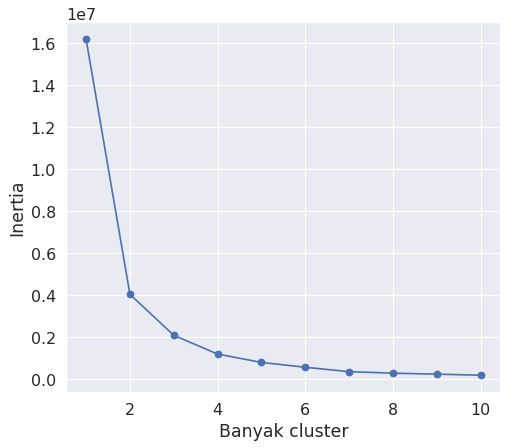

In [ ]:
inertia = []
for i in np.arange(1,11):
    km = KMeans(n_clusters=i)
    km.fit(wine)
    inertia.append(km.inertia_)
plt.figure(figsize=(7, 6), dpi=80)
plt.plot(np.arange(1,11), inertia, marker="o")
plt.xlabel("Banyak cluster")
plt.ylabel("Inertia")
plt.show()

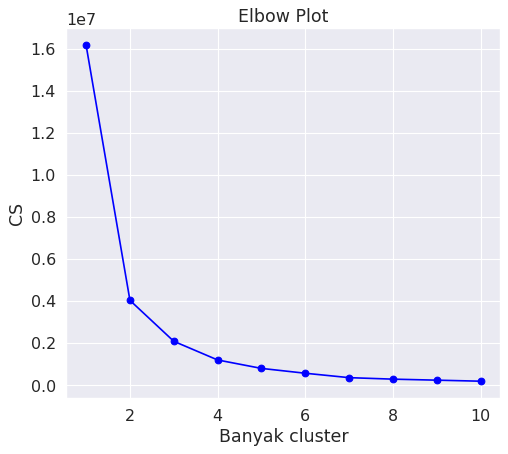

In [ ]:
#CS = cluster sum
cs = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', max_iter = 300, n_init = 10, random_state = 100)
    kmeans.fit(wine)
    cs.append(kmeans.inertia_)

plt.figure(figsize=(7, 6), dpi=80)
plt.plot(range(1, 11), cs, color='blue',  marker="o")
plt.title('Elbow Plot')
plt.xlabel('Banyak cluster')
plt.ylabel('CS')
plt.show()

**Dari hasil grafik-grafik di atas, kita dapat melihat bahwa banyak cluster yang optimal adalah 3 karena terlihat bahwa tidak ada perubahan signifikan setelah angka 3.**

**Modelling**

In [ ]:
kmeans = KMeans(n_clusters=3, init='k-means++',random_state=42)
y = kmeans.fit_predict(wine_scaled)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


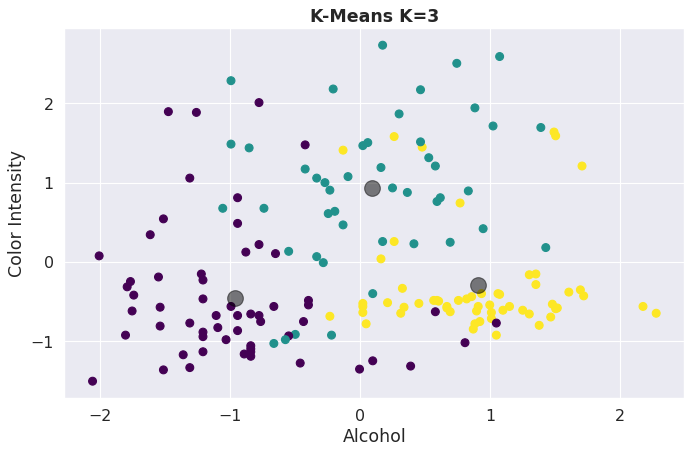

In [ ]:
plt.figure(figsize=(10, 6), dpi=80)
plt.scatter(wine_scaled[:, 0], wine_scaled[:, 1], c=y, s=50, cmap='viridis')

centers = kmeans.cluster_centers_

plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.5);
plt.title('K-Means K=3',fontweight='bold')
plt.xlabel("Alcohol")
plt.ylabel("Color Intensity");

Bintang-bintang merupakan pusatnya. Data dipisahkan menjadi 3 kelompok yaitu,  alkohol rendah dan Color Intensity tinggi (berwarna hijau), alkohol tinggi dan  Color Intensity tinggi (berwarna ungu), dan  Color Intensity rendah (berwarna kuning).

**HIERARCHICAL** **CLUSTERING**



In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage, cophenet, inconsistent, fcluster
from scipy.spatial.distance import pdist
import itertools

In [ ]:
scaled2 = pd.DataFrame(wine_scaled)

In [ ]:
scaled2

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,1.515163,-0.579166,0.270936,-1.248144,2.298023,0.828643,1.055948,-0.650569,1.466583,0.282097,0.383333,1.828097,0.982174
1,0.209648,-0.512507,-0.931537,-2.732175,0.114047,0.589411,0.749315,-0.815257,-0.505150,-0.304357,0.429479,1.096928,0.934830
2,0.158948,0.039806,1.266087,-0.236305,0.194935,0.828643,1.239928,-0.485881,2.481732,0.300715,0.337186,0.773526,1.360929
3,1.692612,-0.350622,0.561189,-0.843409,1.165591,2.503264,1.495455,-0.979945,1.251840,1.287448,-0.447308,1.167233,2.292034
4,0.260347,0.258826,2.095379,0.573166,1.570031,0.828643,0.677767,0.255215,0.549044,-0.332284,0.383333,0.436064,-0.059401
...,...,...,...,...,...,...,...,...,...,...,...,...,...
156,1.426439,0.182645,0.478259,0.235886,-0.613945,-0.957620,-1.356232,0.666936,-0.583238,2.171785,-1.554828,-1.279371,-0.296123
157,0.463146,1.515815,0.478259,1.247725,0.275823,-0.766235,-1.305127,0.584592,-0.251362,1.054728,-1.185655,-1.490285,-0.012057
158,0.298372,1.868152,-0.433962,0.235886,1.731807,-1.101159,-1.366453,0.584592,-0.368495,2.404505,-1.693268,-1.490285,0.256228
159,0.171623,0.258826,0.022149,0.235886,1.731807,-1.005466,-1.376675,1.408032,-0.153752,1.985609,-1.647122,-1.405919,0.272009


In [ ]:
import scipy.cluster.hierarchy as shc

metode = ['single','complete','average']
metrics = ['euclidean','chebyshev']
combination = list(itertools.product(metode, metrics))

CCC,R = [],[]

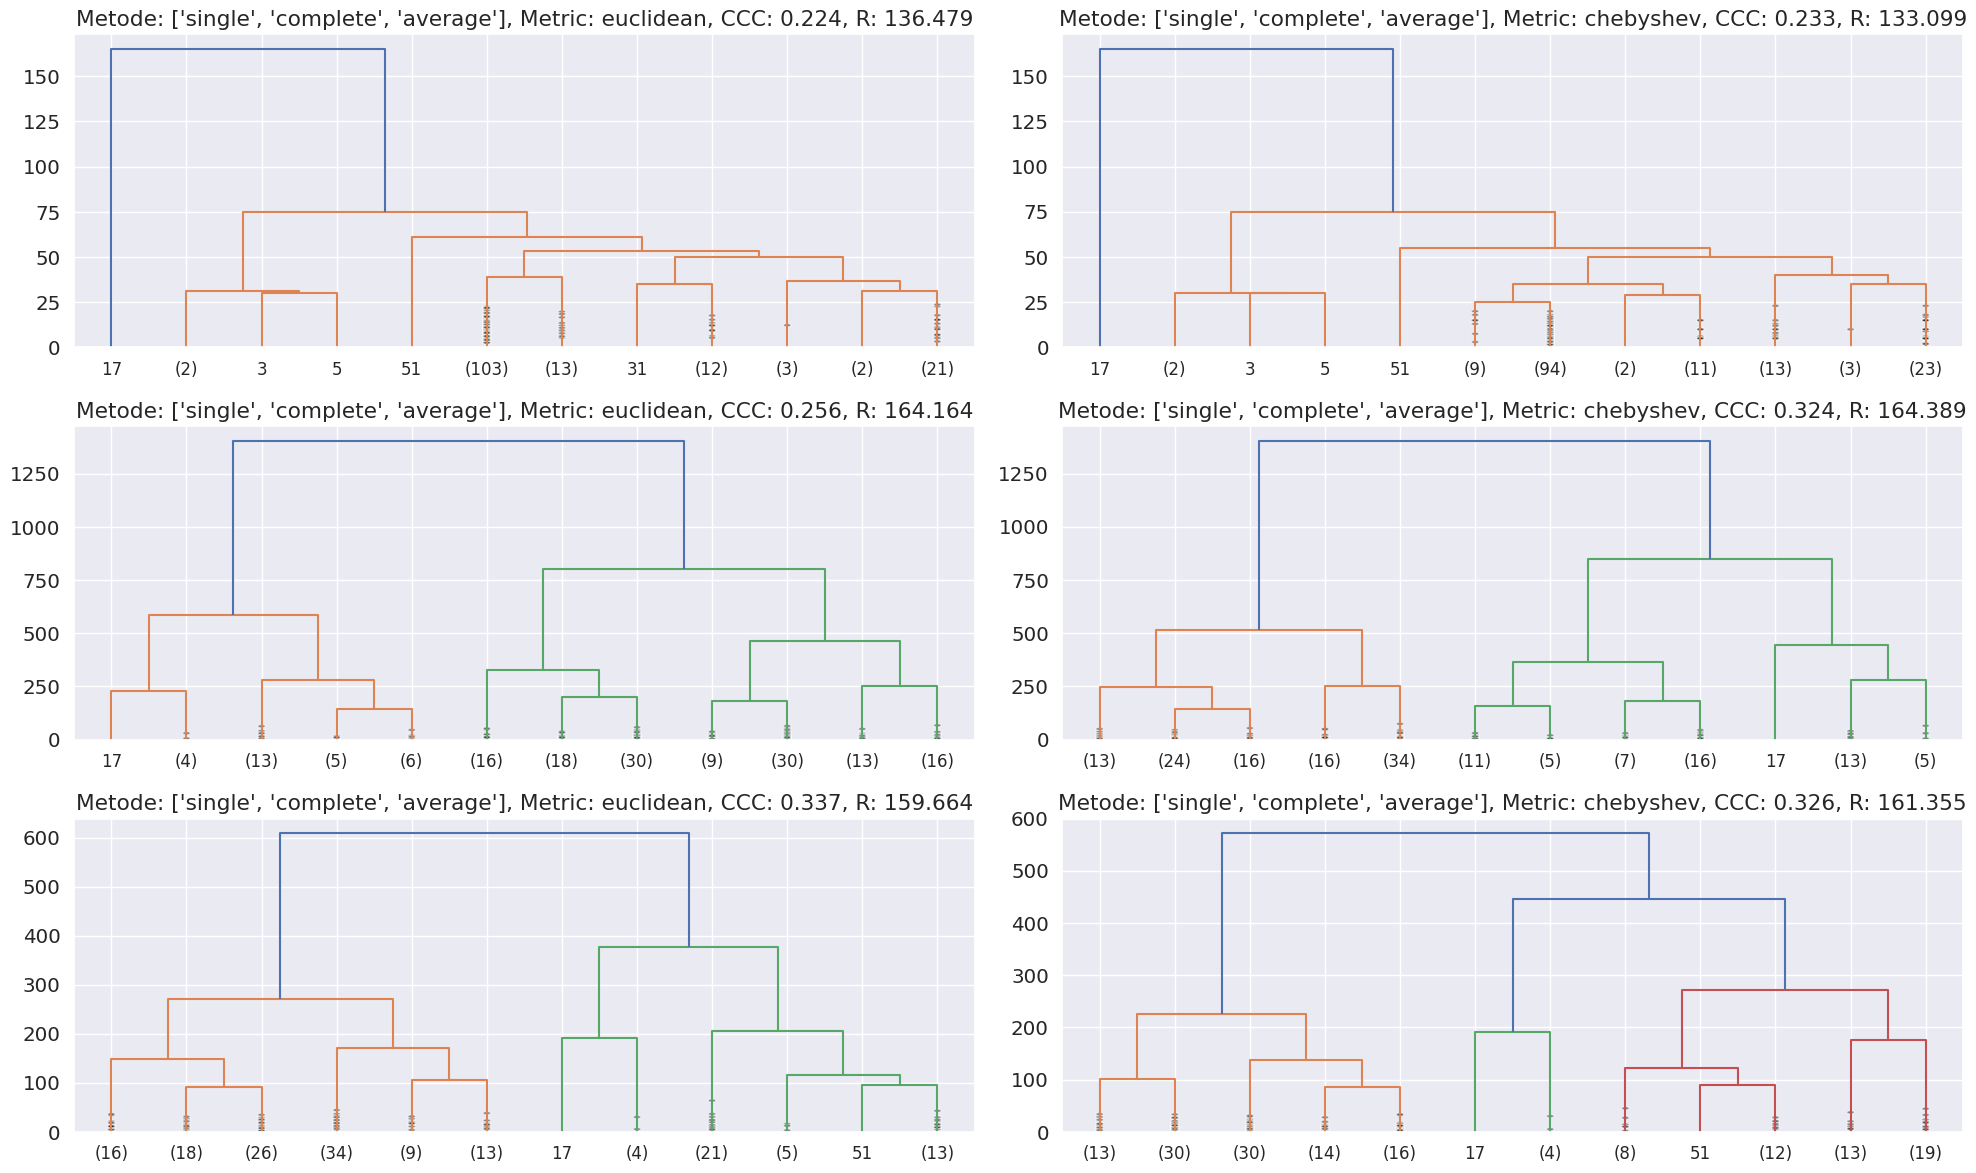

In [ ]:
#meng-plot dendogram untuk setiap pasangan

fig, axes = plt.subplots(len(combination)//2, 2, figsize=(20, 2 * len(combination)))
for i, (method, metric) in enumerate(combination):
    row, col = i // 2, i % 2
    ax = axes[row, col]
    Z = linkage(wine.values, method=method, metric=metric)
    CCC.append(cophenet(Z, pdist(scaled2.values))[0])
    R.append(inconsistent(Z, 5))
    dendrogram(Z, truncate_mode='lastp', p=12, show_contracted=True, labels=scaled2.index, ax=ax)
    ax.set_title('Metode: {}, Metric: {}, CCC: {:.3f}, R: {:.3f}'.format(metode, metric, CCC[-1], np.sum(R[-1][:, 3])))
plt.tight_layout()
plt.show()

In [ ]:
combination=np.array(combination)
CCC = np.array(CCC)
arg = np.argsort(CCC,kind ='quicksort')[::-1]
top_3 = combination[arg[:3]]
print('Top 3 pasangan :')
for i, element in enumerate(top_3):
    print(f'Method : {element[0]}, Metric : {element[1]} dengan CCC = {CCC[arg[i]]}.')

Top 3 pasangan :
Method : average, Metric : euclidean dengan CCC = 0.3371329171271577.
Method : average, Metric : chebyshev dengan CCC = 0.32579368785849316.
Method : complete, Metric : chebyshev dengan CCC = 0.3239971734884634.


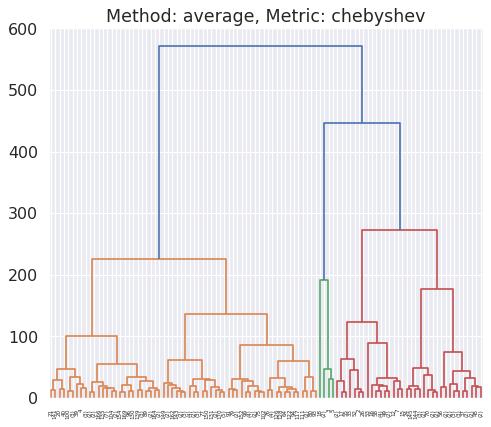

In [ ]:
Z = linkage(wine.values, method='average', metric='chebyshev')
plt.figure(figsize=(7, 6), dpi=80)
dendrogram(Z, truncate_mode='lastp', p=100, show_contracted=True, labels=wine.index)
plt.title('Method: {}, Metric: {}'.format(method, metric))
plt.show()

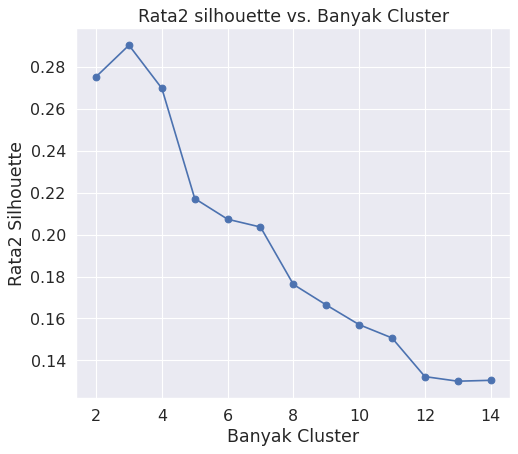

In [ ]:
from sklearn.metrics import silhouette_samples, silhouette_score

silhouette_avg = []
k_values = range(2, 15)

for k in k_values:
    clusters = fcluster(linkage(scaled2.values, method='weighted', metric='euclidean'), k, criterion='maxclust')
    silhouette_avg.append(silhouette_score(scaled2, clusters))

plt.figure(figsize=(7, 6), dpi=80)
plt.plot(k_values, silhouette_avg, marker='o',)
plt.xlabel('Banyak Cluster')
plt.ylabel('Rata2 Silhouette')
plt.title('Rata2 silhouette vs. Banyak Cluster')
plt.show()

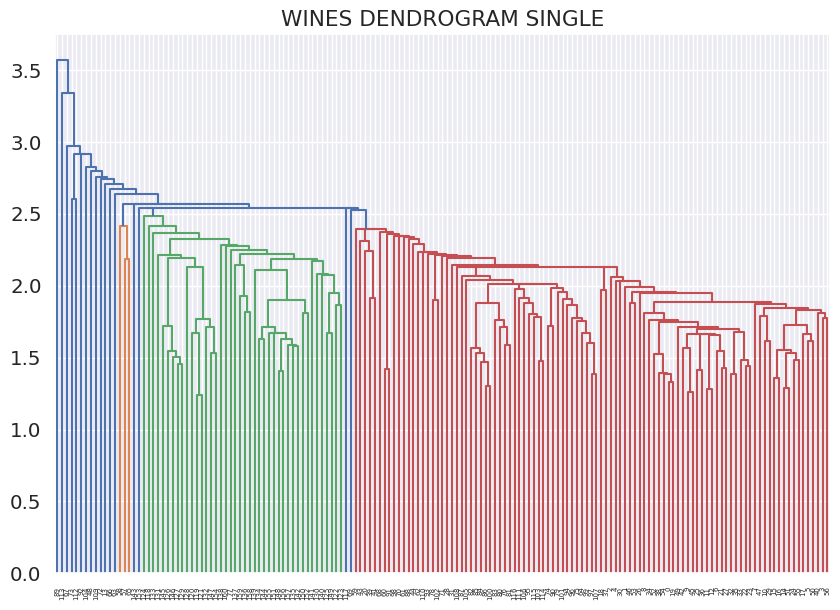

In [ ]:
import scipy.cluster.hierarchy as shc

plt.figure(figsize=(10, 7))
plt.title("WINES DENDROGRAM SINGLE")
dend = shc.dendrogram(shc.linkage(scaled2, method='single'))

In [ ]:
from sklearn.cluster import AgglomerativeClustering

cluster1 = AgglomerativeClustering(n_clusters=8, affinity='euclidean', linkage='single')
types1 = cluster1.fit_predict(scaled2)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_agglomerative.py:983: FutureWarning: Attribute `affinity` was deprecated in version 1.2 and will be removed in 1.4. Use `metric` instead
  warnings.warn(


In [ ]:
types1

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 7, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 3, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 4, 0, 0, 5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 6, 0, 0, 0, 0, 0,
       0, 0, 1, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0])

In [ ]:
scaled3 = pd.DataFrame(types1)

In [ ]:
result_wine_single = pd.concat([scaled3, scaled2], axis=1)

In [ ]:
result_wine_single

,0,0,1,2,3,4,5,6,7,8,9,10,11,12
0,0,1.515163,-0.579166,0.270936,-1.248144,2.298023,0.828643,1.055948,-0.650569,1.466583,0.282097,0.383333,1.828097,0.982174
1,0,0.209648,-0.512507,-0.931537,-2.732175,0.114047,0.589411,0.749315,-0.815257,-0.505150,-0.304357,0.429479,1.096928,0.934830
2,0,0.158948,0.039806,1.266087,-0.236305,0.194935,0.828643,1.239928,-0.485881,2.481732,0.300715,0.337186,0.773526,1.360929
3,0,1.692612,-0.350622,0.561189,-0.843409,1.165591,2.503264,1.495455,-0.979945,1.251840,1.287448,-0.447308,1.167233,2.292034
4,0,0.260347,0.258826,2.095379,0.573166,1.570031,0.828643,0.677767,0.255215,0.549044,-0.332284,0.383333,0.436064,-0.059401
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
156,0,1.426439,0.182645,0.478259,0.235886,-0.613945,-0.957620,-1.356232,0.666936,-0.583238,2.171785,-1.554828,-1.279371,-0.296123
157,0,0.463146,1.515815,0.478259,1.247725,0.275823,-0.766235,-1.305127,0.584592,-0.251362,1.054728,-1.185655,-1.490285,-0.012057
158,0,0.298372,1.868152,-0.433962,0.235886,1.731807,-1.101159,-1.366453,0.584592,-0.368495,2.404505,-1.693268,-1.490285,0.256228
159,0,0.171623,0.258826,0.022149,0.235886,1.731807,-1.005466,-1.376675,1.408032,-0.153752,1.985609,-1.647122,-1.405919,0.272009


In [ ]:
from sklearn.metrics import silhouette_score
silhouette_avg = silhouette_score(result_wine_single, types1)
print("Silhouette Score:", silhouette_avg)

Silhouette Score: 0.04940796595101668


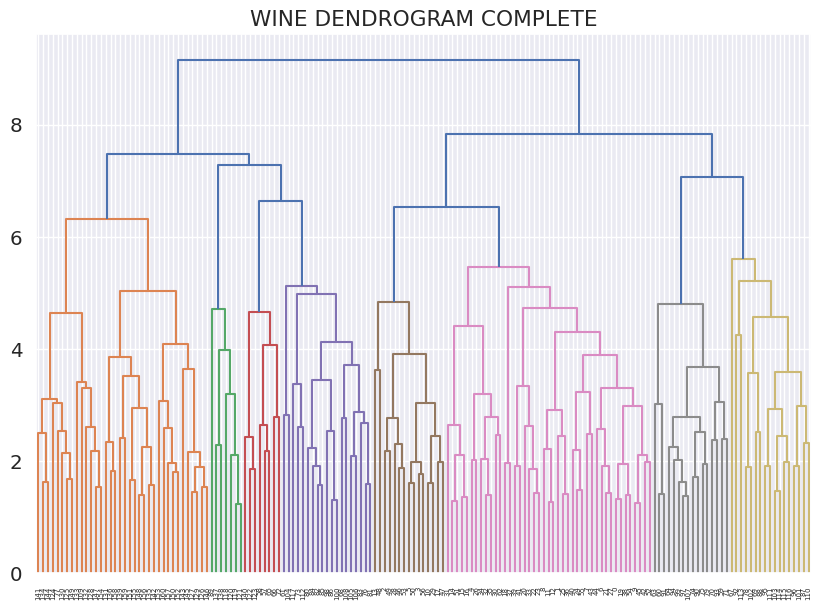

In [ ]:
plt.figure(figsize=(10, 7))
plt.title("WINE DENDROGRAM COMPLETE")
dend = shc.dendrogram(shc.linkage(scaled2, method='complete'))

In [ ]:
cluster2 = AgglomerativeClustering(n_clusters=8, affinity='euclidean', linkage='complete')
types2 = cluster2.fit_predict(scaled2)


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_agglomerative.py:983: FutureWarning: Attribute `affinity` was deprecated in version 1.2 and will be removed in 1.4. Use `metric` instead
  warnings.warn(


In [ ]:
types2

array([3, 3, 7, 7, 3, 7, 3, 3, 3, 3, 7, 3, 3, 7, 3, 3, 3, 7, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 7, 7, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 7, 7, 7, 7, 7, 3, 3, 7, 3, 3, 7, 6, 6, 5, 5, 2, 3, 5, 5, 6,
       6, 1, 2, 1, 5, 5, 6, 2, 5, 5, 2, 0, 1, 5, 2, 2, 2, 2, 2, 2, 2, 1,
       1, 4, 5, 5, 1, 5, 5, 1, 1, 5, 2, 5, 2, 1, 1, 1, 2, 2, 2, 5, 2, 0,
       1, 1, 2, 1, 1, 1, 1, 2, 4, 4, 4, 4, 6, 6, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 4, 4, 0, 6, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0])

In [ ]:
scaled4 = pd.DataFrame(types2)

In [ ]:
result_wine_complete = pd.concat([scaled4, scaled2], axis=1)
result_wine_complete

,0,0,1,2,3,4,5,6,7,8,9,10,11,12
0,3,1.515163,-0.579166,0.270936,-1.248144,2.298023,0.828643,1.055948,-0.650569,1.466583,0.282097,0.383333,1.828097,0.982174
1,3,0.209648,-0.512507,-0.931537,-2.732175,0.114047,0.589411,0.749315,-0.815257,-0.505150,-0.304357,0.429479,1.096928,0.934830
2,7,0.158948,0.039806,1.266087,-0.236305,0.194935,0.828643,1.239928,-0.485881,2.481732,0.300715,0.337186,0.773526,1.360929
3,7,1.692612,-0.350622,0.561189,-0.843409,1.165591,2.503264,1.495455,-0.979945,1.251840,1.287448,-0.447308,1.167233,2.292034
4,3,0.260347,0.258826,2.095379,0.573166,1.570031,0.828643,0.677767,0.255215,0.549044,-0.332284,0.383333,0.436064,-0.059401
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
156,0,1.426439,0.182645,0.478259,0.235886,-0.613945,-0.957620,-1.356232,0.666936,-0.583238,2.171785,-1.554828,-1.279371,-0.296123
157,0,0.463146,1.515815,0.478259,1.247725,0.275823,-0.766235,-1.305127,0.584592,-0.251362,1.054728,-1.185655,-1.490285,-0.012057
158,0,0.298372,1.868152,-0.433962,0.235886,1.731807,-1.101159,-1.366453,0.584592,-0.368495,2.404505,-1.693268,-1.490285,0.256228
159,0,0.171623,0.258826,0.022149,0.235886,1.731807,-1.005466,-1.376675,1.408032,-0.153752,1.985609,-1.647122,-1.405919,0.272009


In [ ]:
from sklearn.metrics import silhouette_score
silhouette_avg = silhouette_score(result_wine_complete, types2)
print("Silhouette Score:", silhouette_avg)

Silhouette Score: 0.325479876490825


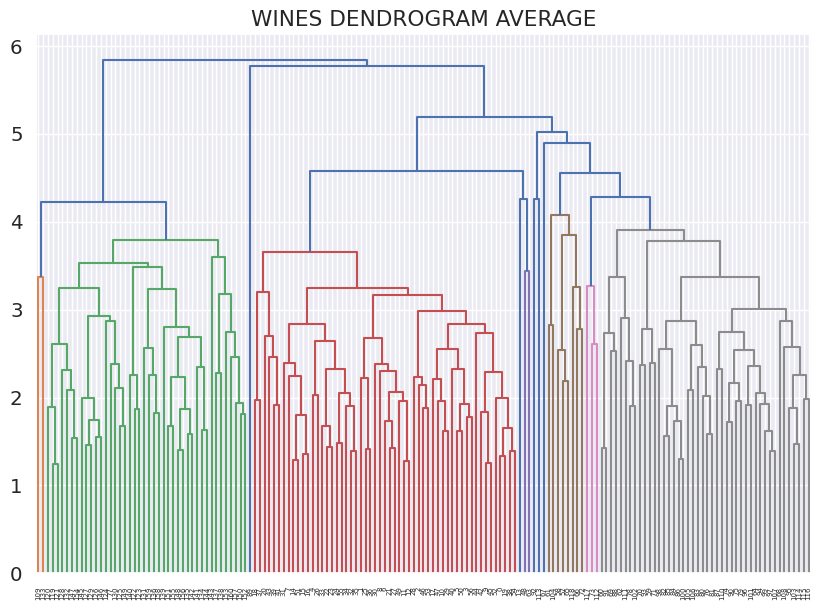

In [ ]:
plt.figure(figsize=(10, 7))
plt.title("WINES DENDROGRAM AVERAGE")
dend = shc.dendrogram(shc.linkage(scaled2, method='average'))

In [ ]:
cluster3 = AgglomerativeClustering(n_clusters=8, affinity='euclidean', linkage='average')
types3 = cluster3.fit_predict(scaled2)


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_agglomerative.py:983: FutureWarning: Attribute `affinity` was deprecated in version 1.2 and will be removed in 1.4. Use `metric` instead
  warnings.warn(


In [ ]:
types3

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 4, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 4, 2, 2, 2, 2, 2, 2, 2, 2, 7, 7, 0, 0, 7, 0, 4, 0, 7,
       7, 5, 0, 0, 0, 0, 7, 0, 0, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 6, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 7, 0, 0, 0, 0, 3,
       0, 0, 0, 1, 0, 0, 0, 0, 7, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3])

In [ ]:
scaled5 = pd.DataFrame(types3)
result_wine_average = pd.concat([scaled5, scaled2], axis=1)
result_wine_average

,0,0,1,2,3,4,5,6,7,8,9,10,11,12
0,2,1.515163,-0.579166,0.270936,-1.248144,2.298023,0.828643,1.055948,-0.650569,1.466583,0.282097,0.383333,1.828097,0.982174
1,2,0.209648,-0.512507,-0.931537,-2.732175,0.114047,0.589411,0.749315,-0.815257,-0.505150,-0.304357,0.429479,1.096928,0.934830
2,2,0.158948,0.039806,1.266087,-0.236305,0.194935,0.828643,1.239928,-0.485881,2.481732,0.300715,0.337186,0.773526,1.360929
3,2,1.692612,-0.350622,0.561189,-0.843409,1.165591,2.503264,1.495455,-0.979945,1.251840,1.287448,-0.447308,1.167233,2.292034
4,2,0.260347,0.258826,2.095379,0.573166,1.570031,0.828643,0.677767,0.255215,0.549044,-0.332284,0.383333,0.436064,-0.059401
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
156,3,1.426439,0.182645,0.478259,0.235886,-0.613945,-0.957620,-1.356232,0.666936,-0.583238,2.171785,-1.554828,-1.279371,-0.296123
157,3,0.463146,1.515815,0.478259,1.247725,0.275823,-0.766235,-1.305127,0.584592,-0.251362,1.054728,-1.185655,-1.490285,-0.012057
158,3,0.298372,1.868152,-0.433962,0.235886,1.731807,-1.101159,-1.366453,0.584592,-0.368495,2.404505,-1.693268,-1.490285,0.256228
159,3,0.171623,0.258826,0.022149,0.235886,1.731807,-1.005466,-1.376675,1.408032,-0.153752,1.985609,-1.647122,-1.405919,0.272009


In [ ]:
silhouette_avg = silhouette_score(result_wine_average, types3)
print("Silhouette Score:", silhouette_avg)

Silhouette Score: 0.3220237322193135


**CLUSTERING DENSITY**


---
Menggunakan DBSCAN (Density-Based Spatial Clustering of Applications with Noise)

DBSCAN merupakan salah satu metode clustering yang berbasiskan tingkat kerapatan data (density-based) dari posisi amatan data dengan prinsip mengelompokkan data yang relatif berdekatan. Dimana metode ini memunculkan daerah yang memiliki kerapatan tinggi menjadi cluster-cluster, dan menemukan cluster-cluster tersebut pada bentuk bebas dalam sebuah ruang database dengan memanfaatkan noise.

In [ ]:
from sklearn.cluster import DBSCAN

In [ ]:
from sklearn.preprocessing import MinMaxScaler
# Memilih kolom untuk dilakukan Min-Max Scaling
scaled_columns = ['Alcohol', 'Color_Intensity']

scaler = MinMaxScaler()

# Melakukan Min-Max Scaling pada kolom yang dipilih
wine[scaled_columns] = scaler.fit_transform(wine[scaled_columns])

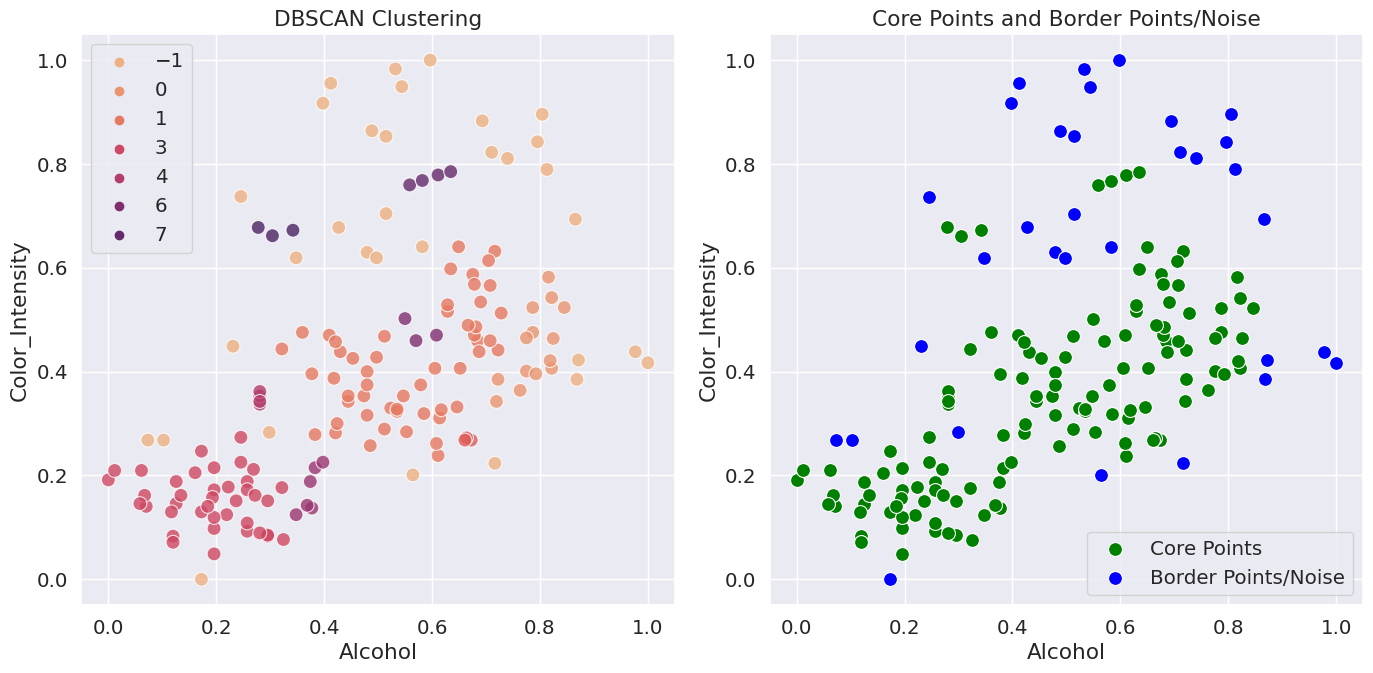

In [ ]:
#Menginisialisasi kolom yang dipilih untuk dilakukan DBSCAN
features = wine[['Alcohol', 'Color_Intensity']]

# melakukan DBSCAN clustering dengan epsilon = 0.05 dan density = 3
dbscan = DBSCAN(eps=0.05, min_samples=3)
wine['Cluster'] = dbscan.fit_predict(features)

plt.figure(figsize=(14, 7))

# Scatter plot for semua points
plt.subplot(1, 2, 1)
sns.scatterplot(x='Alcohol', y='Color_Intensity', hue='Cluster', data=wine, palette='flare', s=100, alpha=0.8)
plt.title('DBSCAN Clustering')
plt.xlabel('Alcohol')
plt.ylabel('Color_Intensity')
plt.legend()

# Scatter plot untuk core points, border points, dan noise points
core_points = wine[wine['Cluster'] != -1]
border_points = wine[wine['Cluster'] == -1]

plt.subplot(1, 2, 2)
sns.scatterplot(x='Alcohol', y='Color_Intensity', data=core_points, color='green', s=100, label='Core Points')
sns.scatterplot(x='Alcohol', y='Color_Intensity', data=border_points, color='blue', s=100, label='Border Points/Noise')
plt.title('Core Points and Border Points/Noise')
plt.xlabel('Alcohol')
plt.ylabel('Color_Intensity')
plt.legend()

plt.tight_layout()
plt.show()

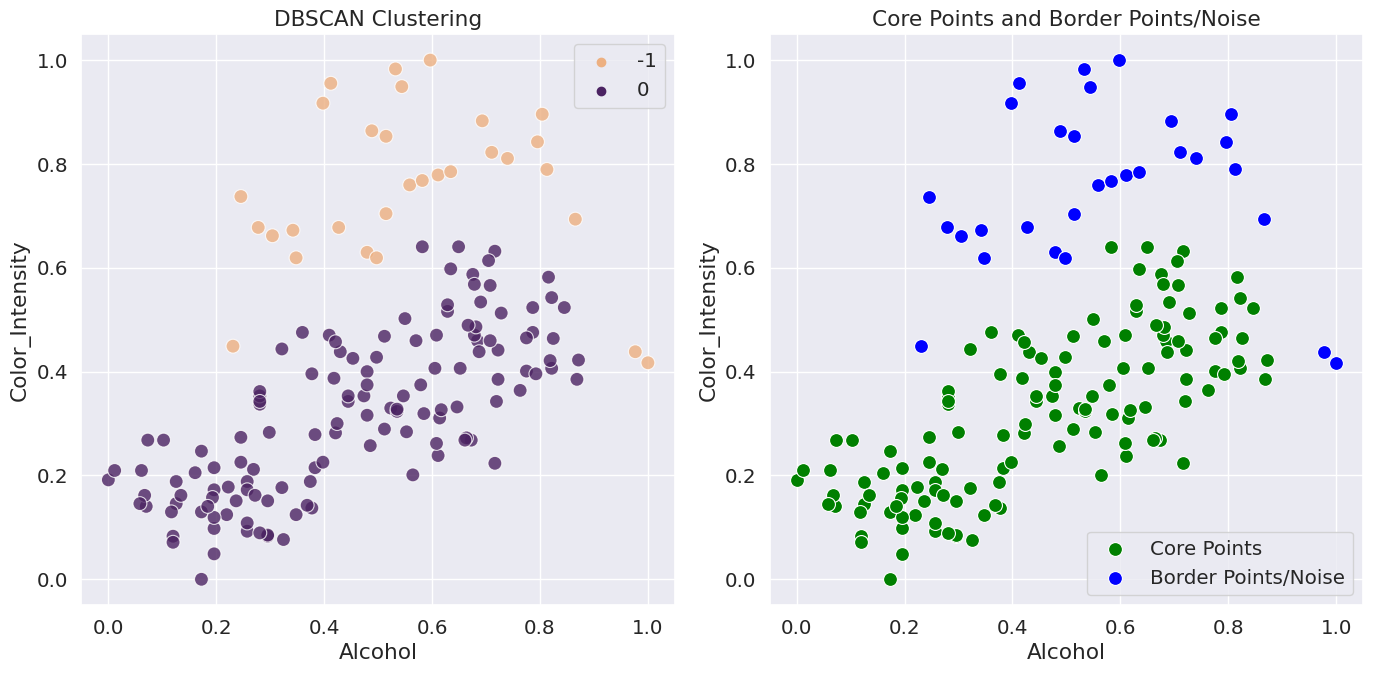

In [ ]:
#Menginisialisasi kolom yang dipilih untuk dilakukan DBSCAN
features = wine[['Alcohol', 'Color_Intensity']]

# melakukan DBSCAN clustering dengan epsilon = 0.1 dan density = 8
dbscan = DBSCAN(eps=0.1, min_samples=8)
wine['Cluster'] = dbscan.fit_predict(features)

plt.figure(figsize=(14, 7))

# Scatter plot for semua points
plt.subplot(1, 2, 1)
sns.scatterplot(x='Alcohol', y='Color_Intensity', hue='Cluster', data=wine, palette='flare', s=100, alpha=0.8)
plt.title('DBSCAN Clustering')
plt.xlabel('Alcohol')
plt.ylabel('Color_Intensity')
plt.legend()

# Scatter plot untuk core points, border points, dan noise points
core_points = wine[wine['Cluster'] != -1]
border_points = wine[wine['Cluster'] == -1]

plt.subplot(1, 2, 2)
sns.scatterplot(x='Alcohol', y='Color_Intensity', data=core_points, color='green', s=100, label='Core Points')
sns.scatterplot(x='Alcohol', y='Color_Intensity', data=border_points, color='blue', s=100, label='Border Points/Noise')
plt.title('Core Points and Border Points/Noise')
plt.xlabel('Alcohol')
plt.ylabel('Color_Intensity')
plt.legend()

plt.tight_layout()
plt.show()

Melihat adanya perbedaan yang signifikan pada scatter plot saat parameter dan tingkat kepadatannya berubah, maka dapat disimpulkan bahwa metode DBSCAN ini sangat sensitif terhadap perubahan parameter.